# Evaluation and error analysis

A model evaluation should state the decision being measured, the data used to select it, and the uncertainty in the reported result. A single test metric does not describe that procedure.


## Choosing an operating point

The example requires validation recall of at least `0.80`. Candidate thresholds are evaluated on validation data. Among the thresholds that satisfy the requirement, the one with the smallest false-positive rate is selected.


In [1]:
import numpy as np

rng = np.random.default_rng(101)
n = 1200
group = rng.choice(['A', 'B'], size=n, p=[0.7, 0.3])
signal = rng.normal(size=n)
group_effect = np.where(group == 'A', 0.3, -0.2)
true_probability = 1 / (1 + np.exp(-(1.1 * signal + group_effect)))
y = rng.binomial(1, true_probability)

# Model scores are noisy estimates, not ground-truth probabilities.
scores = np.clip(true_probability + rng.normal(0, 0.12, size=n), 0, 1)
order = rng.permutation(n)
train, validation, test = order[:600], order[600:900], order[900:]
print('positive rate:', y.mean())
print('split sizes:', len(train), len(validation), len(test))

positive rate: 0.5233333333333333
split sizes: 600 300 300


## Threshold-dependent metrics

Precision is the fraction of predicted positives that are correct. Recall is the fraction of actual positives recovered. False-positive rate is the fraction of actual negatives classified as positive. Changing the threshold changes all three quantities.


In [2]:
def metrics_at_threshold(y, scores, threshold):
    predicted = scores >= threshold
    actual = y == 1
    tp = np.sum(predicted & actual)
    fp = np.sum(predicted & ~actual)
    fn = np.sum(~predicted & actual)
    tn = np.sum(~predicted & ~actual)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    fpr = fp / max(fp + tn, 1)
    accuracy = (tp + tn) / len(y)
    return {'threshold': threshold, 'precision': precision,
            'recall': recall, 'fpr': fpr, 'accuracy': accuracy,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

for threshold in [0.3, 0.5, 0.7]:
    print(metrics_at_threshold(y[validation], scores[validation], threshold))

{'threshold': 0.3, 'precision': np.float64(0.6483050847457628), 'recall': np.float64(0.9161676646706587), 'fpr': np.float64(0.6240601503759399), 'accuracy': np.float64(0.6766666666666666), 'tp': np.int64(153), 'fp': np.int64(83), 'fn': np.int64(14), 'tn': np.int64(50)}
{'threshold': 0.5, 'precision': np.float64(0.7421383647798742), 'recall': np.float64(0.7065868263473054), 'fpr': np.float64(0.3082706766917293), 'accuracy': np.float64(0.7), 'tp': np.int64(118), 'fp': np.int64(41), 'fn': np.int64(49), 'tn': np.int64(92)}
{'threshold': 0.7, 'precision': np.float64(0.7804878048780488), 'recall': np.float64(0.38323353293413176), 'fpr': np.float64(0.13533834586466165), 'accuracy': np.float64(0.5966666666666667), 'tp': np.int64(64), 'fp': np.int64(18), 'fn': np.int64(103), 'tn': np.int64(115)}


## Ranking metrics

ROC-AUC and PR-AUC describe the ordering of scores across thresholds. They are useful for comparing ranking behaviour, but they do not by themselves specify the threshold that should be used by an application.


chosen validation operating point: {'threshold': np.float64(0.43999999999999995), 'precision': np.float64(0.7165775401069518), 'recall': np.float64(0.8023952095808383), 'fpr': np.float64(0.39849624060150374), 'accuracy': np.float64(0.7133333333333334), 'tp': np.int64(134), 'fp': np.int64(53), 'fn': np.int64(33), 'tn': np.int64(80)}
single final test evaluation: {'threshold': np.float64(0.43999999999999995), 'precision': np.float64(0.6162162162162163), 'recall': np.float64(0.75), 'fpr': np.float64(0.4797297297297297), 'accuracy': np.float64(0.6366666666666667), 'tp': np.int64(114), 'fp': np.int64(71), 'fn': np.int64(38), 'tn': np.int64(77)}


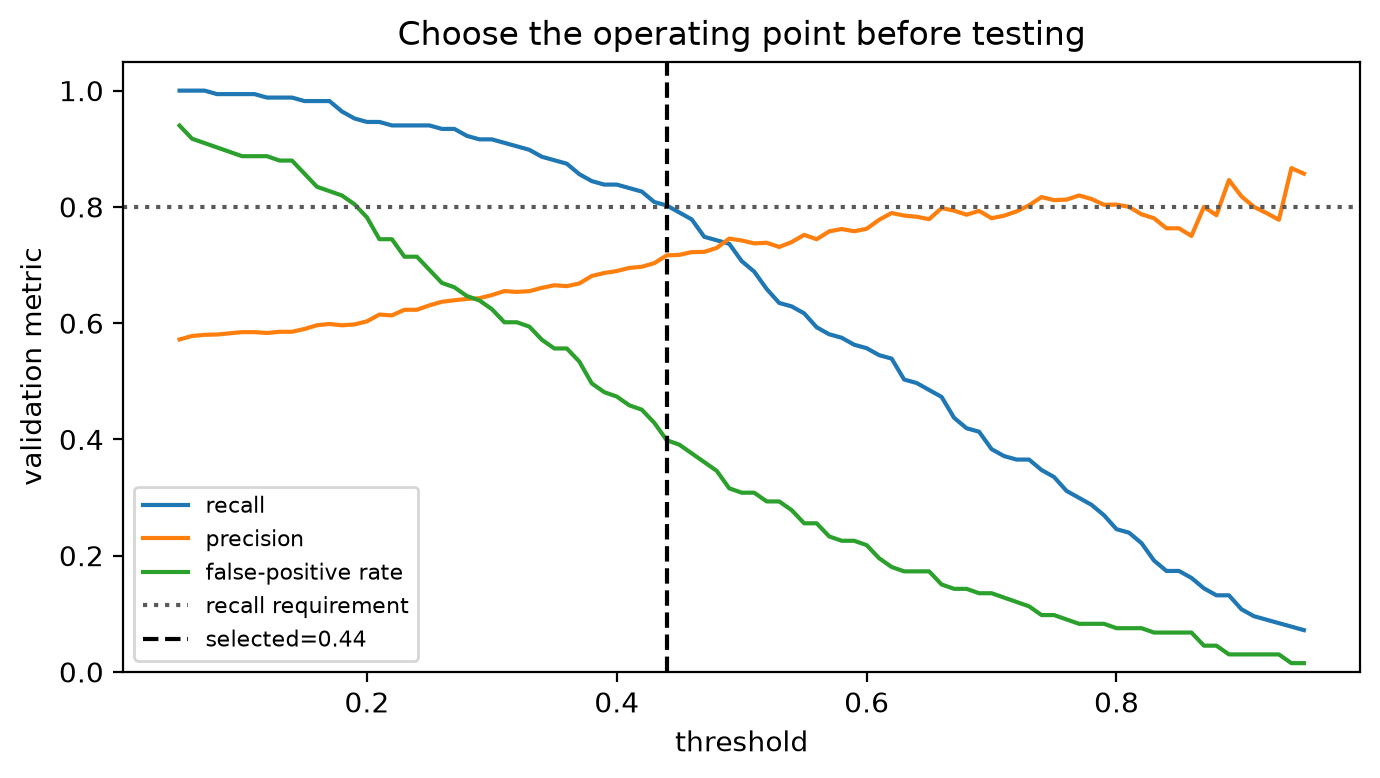

In [3]:
import matplotlib.pyplot as plt

thresholds = np.linspace(0.05, 0.95, 91)
validation_metrics = [metrics_at_threshold(y[validation], scores[validation], threshold) for threshold in thresholds]
eligible = [metric for metric in validation_metrics if metric['recall'] >= 0.80]
chosen = min(eligible, key=lambda metric: metric['fpr'])
test_metrics = metrics_at_threshold(y[test], scores[test], chosen['threshold'])
print('chosen validation operating point:', chosen)
print('single final test evaluation:', test_metrics)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, [metric['recall'] for metric in validation_metrics], label='recall')
ax.plot(thresholds, [metric['precision'] for metric in validation_metrics], label='precision')
ax.plot(thresholds, [metric['fpr'] for metric in validation_metrics], label='false-positive rate')
ax.axhline(0.80, color='0.35', linestyle=':', label='recall requirement')
ax.axvline(chosen['threshold'], color='black', linestyle='--', label=f"selected={chosen['threshold']:.2f}")
ax.set(xlabel='threshold', ylabel='validation metric', ylim=(0, 1.05), title='Choose the operating point before testing')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Test evaluation and bootstrap uncertainty

After the validation threshold is fixed, it is applied once to the test data. The bootstrap interval resamples those test observations and describes sampling variation in accuracy. It does not account for distribution shift, label noise, or future changes in the population.


bootstrap accuracy interval: [0.58  0.637 0.69 ]
group A: n=215, {'threshold': np.float64(0.43999999999999995), 'precision': np.float64(0.6716417910447762), 'recall': np.float64(0.7692307692307693), 'fpr': np.float64(0.4489795918367347), 'accuracy': np.float64(0.6697674418604651), 'tp': np.int64(90), 'fp': np.int64(44), 'fn': np.int64(27), 'tn': np.int64(54)}
group B: n=85, {'threshold': np.float64(0.43999999999999995), 'precision': np.float64(0.47058823529411764), 'recall': np.float64(0.6857142857142857), 'fpr': np.float64(0.54), 'accuracy': np.float64(0.5529411764705883), 'tp': np.int64(24), 'fp': np.int64(27), 'fn': np.int64(11), 'tn': np.int64(23)}


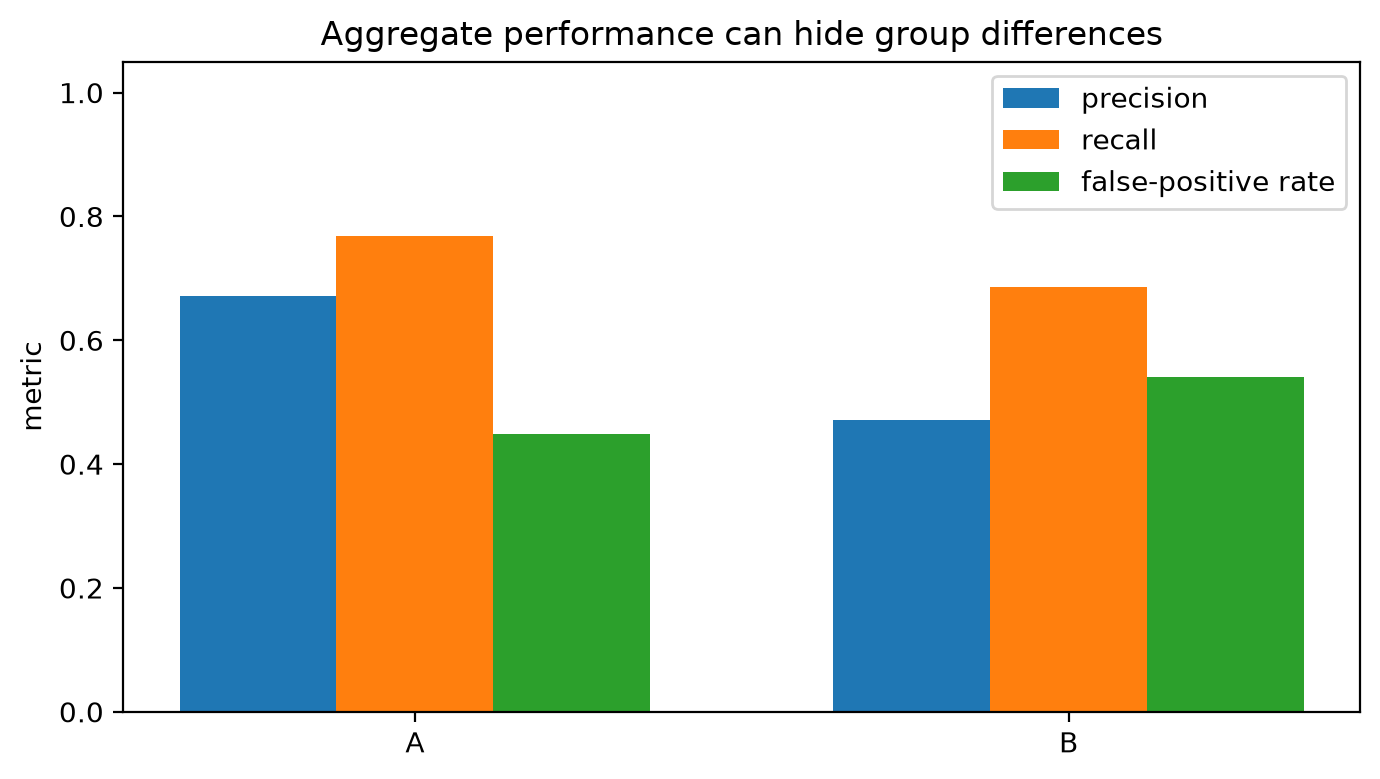

In [4]:
def bootstrap_accuracy(y, scores, threshold, repetitions=1_000, seed=0):
    local_rng = np.random.default_rng(seed)
    values = []
    for _ in range(repetitions):
        sample = local_rng.integers(0, len(y), size=len(y))
        predicted = scores[sample] >= threshold
        values.append(np.mean(predicted == (y[sample] == 1)))
    return np.quantile(values, [0.025, 0.5, 0.975])

interval = bootstrap_accuracy(y[test], scores[test], chosen['threshold'])
print('bootstrap accuracy interval:', np.round(interval, 3))
group_rows = []
for name in ['A', 'B']:
    mask = group[test] == name
    metrics = metrics_at_threshold(y[test][mask], scores[test][mask], chosen['threshold'])
    group_rows.append((name, mask.sum(), metrics['precision'], metrics['recall'], metrics['fpr']))
    print(f'group {name}: n={mask.sum()}, {metrics}')

labels = [row[0] for row in group_rows]
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(labels))
width = 0.24
for offset, metric, label in [(-width, 2, 'precision'), (0, 3, 'recall'), (width, 4, 'false-positive rate')]:
    ax.bar(x + offset, [row[metric] for row in group_rows], width=width, label=label)
ax.set(xticks=x, xticklabels=labels, ylim=(0, 1.05), ylabel='metric', title='Aggregate performance can hide group differences')
ax.legend()
fig.tight_layout()
plt.show()


## Group-level errors

The final output reports precision, recall, and false-positive rate for groups A and B separately. An aggregate metric can hide different operating behaviour between groups, especially when the group sizes are unequal.
